In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from xgboost import XGBClassifier

In [6]:
#DataFlair - Read the data
df=pd.read_csv('D:\projects\Parkinsons\data\parkinsons\parkinsons.data')
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


# Exploratory Data Analysis (EDA)
This notebook performs exploratory data analysis on the Parkinson's dataset to understand its characteristics, feature distributions, correlations, and train a baseline XGBoost classifier.

## 1. Dataset Shape

In [11]:
df.shape

(195, 24)

### Observations: Shape
- The dataset contains **195 rows** and **24 columns**.
- Each row represents a specific voice recording from a subject, and columns correspond to various biomedical voice measurements, a patient identifier, and the target diagnosis status.

## 2. Dataset Info

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    str    
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 17  status  

### Observations: Info
- **Data Types**: The dataset consists of:
  - **22 float64** columns (biomedical voice features).
  - **1 int64** column (`status`, the binary target variable where `1` = Parkinson's, `0` = Healthy).
  - **1 object (string)** column (`name`, the voice recording identifier).
- **Data Quality**: The non-null counts match the total index count of 195, suggesting there are no obvious missing values. We will verify this explicitly with `isnull().sum()`.

## 3. Check for Null / Missing Values

In [13]:
df.isnull().sum()

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

### Observations: Missing Values
- Confirming that there are **0 null/missing values** across all columns in the dataset.
- No imputation or deletion strategies for missing values are needed.

## 4. Descriptive Statistics

In [14]:
df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


### Observations: Descriptive Statistics
- **Feature Scale Disparity**:
  - Vocal frequencies (`MDVP:Fo(Hz)`, `MDVP:Fhi(Hz)`, `MDVP:Flo(Hz)`) have a large scale, with `MDVP:Fhi(Hz)` going up to **592.03 Hz** and minimum frequency at **65.48 Hz**.
  - Jitter and shimmer features (representing frequency/amplitude variations) are very small decimals (e.g., `MDVP:Jitter(Abs)` has a mean of **0.000044**).
  - Nonlinear measures like `spread1` range from -7.96 to -2.43, and `D2` ranges from 1.42 to 3.67.
  - These significant differences in feature scaling suggest that feature scaling (such as standardization or min-max scaling) will be important for linear or distance-based models.

## 5. Class Distribution

In [15]:
df["status"].value_counts()

status
1    147
0     48
Name: count, dtype: int64

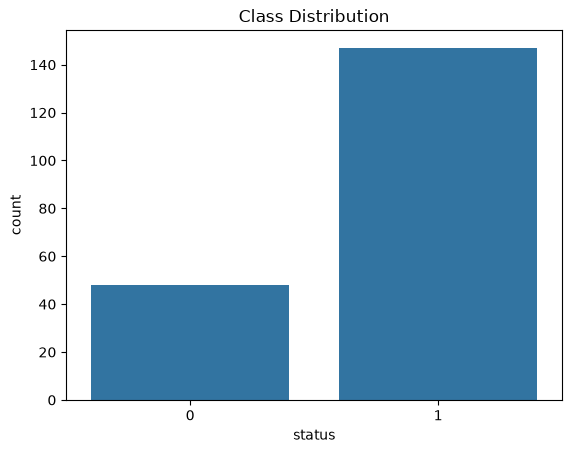

In [16]:
sns.countplot(x="status", data=df)
plt.title("Class Distribution")
plt.show()

### Observation: Class Distribution
- The dataset is moderately imbalanced with more Parkinson's patients (`status = 1`, **147 cases**) than healthy individuals (`status = 0`, **48 cases**).
- Approximately **75.4%** of the samples represent Parkinson's disease subjects. We should use stratified splits and focus on evaluation metrics like F1-score, Precision, and Recall rather than just raw accuracy.

## 6. Correlation Heatmap

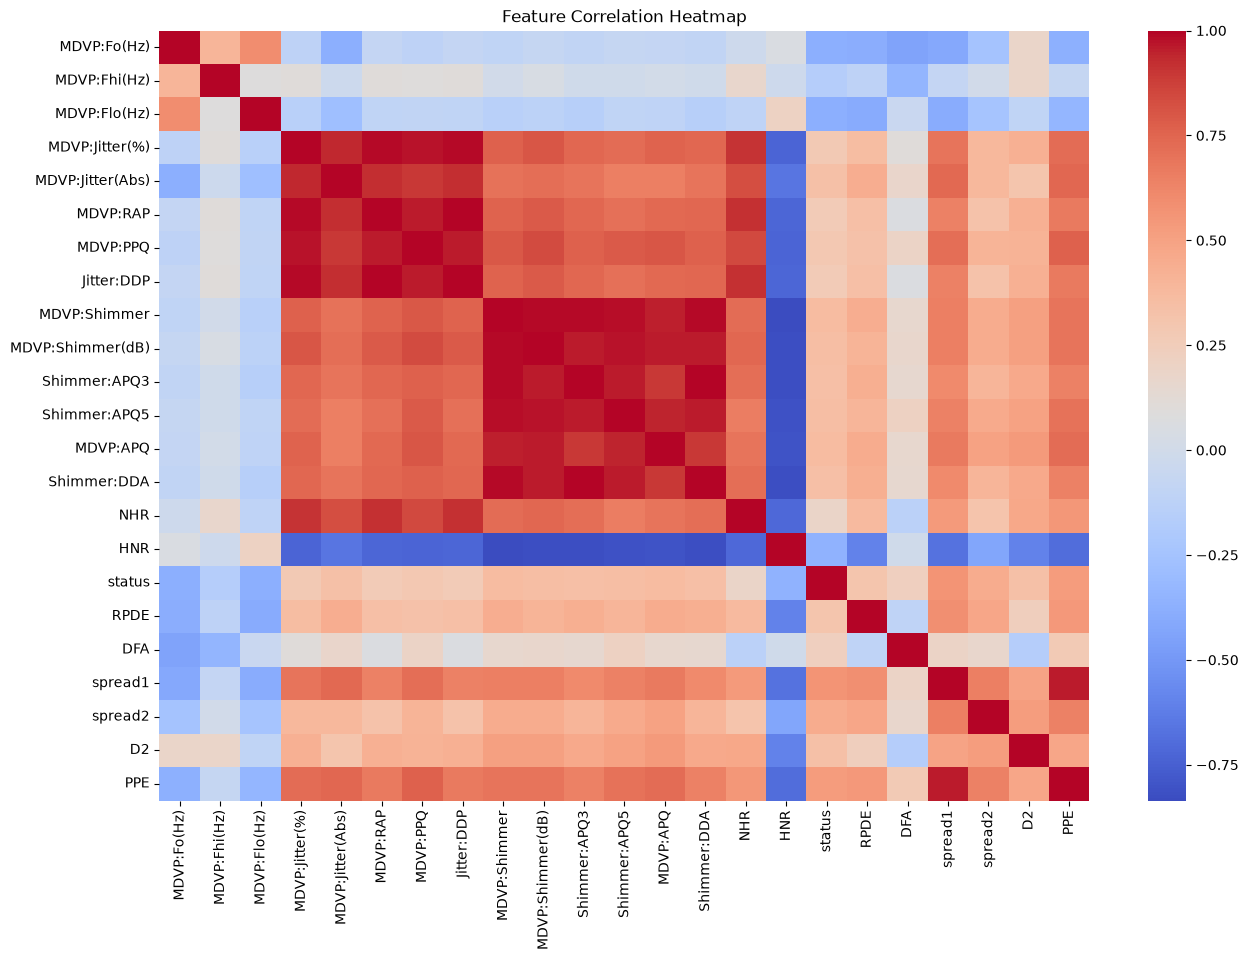

In [17]:
plt.figure(figsize=(15,10))
sns.heatmap(
    df.drop("name", axis=1).corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Feature Correlation Heatmap")
plt.show()

### Observation: Correlation
- Several jitter and shimmer features show strong positive correlations with each other (indicated by the deep red blocks on the heatmap).
- This is expected since these features measure variations in frequency (jitter) and amplitude (shimmer) in the voice, which tend to co-vary.
- Multi-collinearity is present, which tree-based models like XGBoost handle relatively well, but we should be cautious if using linear models.

## 7. Train Baseline XGBoost Model

In [18]:
X = df.drop(["name", "status"], axis=1)
y = df["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)



,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [28]:

joblib.dump(
    model,
    "../models/xgboost_model.pkl"
)

['../models/xgboost_model.pkl']

In [20]:
pred = model.predict(X_test)

In [21]:
print("Classification Report:")
print(classification_report(y_test, pred))
print(f"Accuracy Score: {accuracy_score(y_test, pred):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39

Accuracy Score: 0.9231


### Observation: Baseline XGBoost Performance
- The baseline XGBoost model achieves an **accuracy of 92.31%** on the test set.
- **Recall for class 1 (Parkinson's)** is very high at **97%** (28 out of 29 cases detected), which is crucial for a medical screening tool.
- **Recall for class 0 (Healthy)** is **80%** (8 out of 10 cases), suggesting some false positives, likely due to class imbalance.

## 8. Feature Importance

In [22]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

importance

,Feature,Importance
21,PPE,0.216699
18,spread1,0.196355
14,NHR,0.096487
3,MDVP:Jitter(%),0.056666
2,MDVP:Flo(Hz),0.055258
9,MDVP:Shimmer(dB),0.053470
8,MDVP:Shimmer,0.042100
0,MDVP:Fo(Hz),0.040522
12,MDVP:APQ,0.037246
11,Shimmer:APQ5,0.032513


C:\Users\varsh\AppData\Local\Temp\ipykernel_11796\2077019324.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance, palette="viridis")


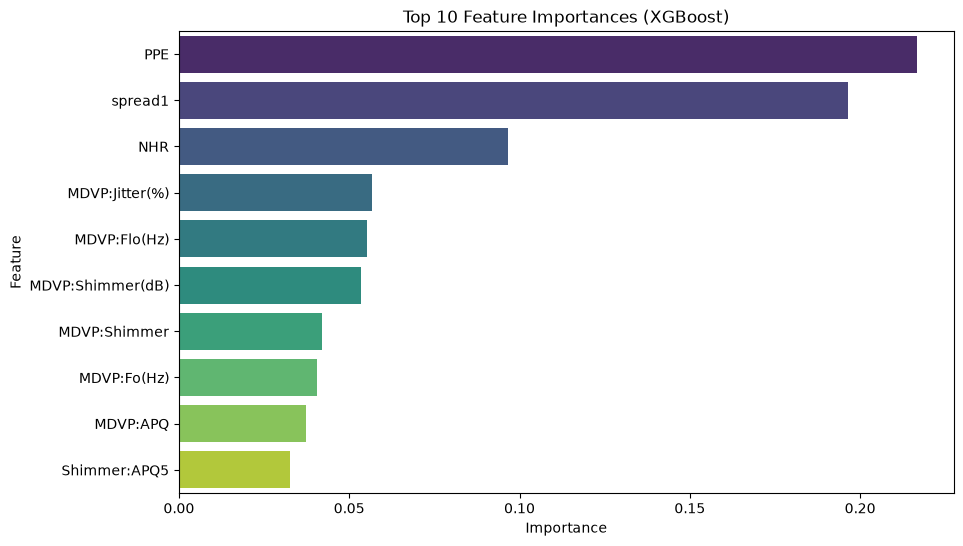

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance, palette="viridis")
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()

### Observation: Feature Importance
- **PPE (Pitch Period Entropy)** is the most important feature with an importance score of **~0.217**.
- **spread1** is the second most important feature with **~0.196**.
- **NHR (Noise-to-Harmonics Ratio)** is third with **~0.096**.
- Together, `PPE` and `spread1` (both nonlinear measures of fundamental frequency variation) account for over **40%** of the model's split decisions. This aligns with clinical knowledge, as vocal tremor and difficulties in maintaining steady fundamental frequency are primary characteristics of Parkinson's Disease voice impairment.